In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse")

INPUT_FILE = PROJECT_DIR / "data" / "metadata" / "speech_features.csv"
OUTPUT_FILE = PROJECT_DIR / "data" / "processed" / "speech_features_normalized.csv"

df = pd.read_csv(INPUT_FILE)

exclude_cols = [
    "file_id",
    "dataset",
    "file",
    "speaker",
    "emotion",
    "emotion_id"
]

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

X = df[feature_cols].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

normalized_df = df.copy()
normalized_df[feature_cols] = X_scaled

OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
normalized_df.to_csv(OUTPUT_FILE, index=False)

print("=" * 50)
print("Speech normalization complete")
print("=" * 50)
print("Original shape :", df.shape)
print("Normalized shape:", normalized_df.shape)
print("Features normalized:", len(feature_cols))
print("Saved to:", OUTPUT_FILE)

print("\nMean after normalization:")
print(normalized_df[feature_cols].mean().abs().mean())

print("\nAverage standard deviation:")
print(normalized_df[feature_cols].std().mean())

Speech normalization complete
Original shape : (10322, 51)
Normalized shape: (10322, 51)
Features normalized: 45
Saved to: C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\processed\speech_features_normalized.csv

Mean after normalization:
1.2164386391018788e-16

Average standard deviation:
0.9778251449948471


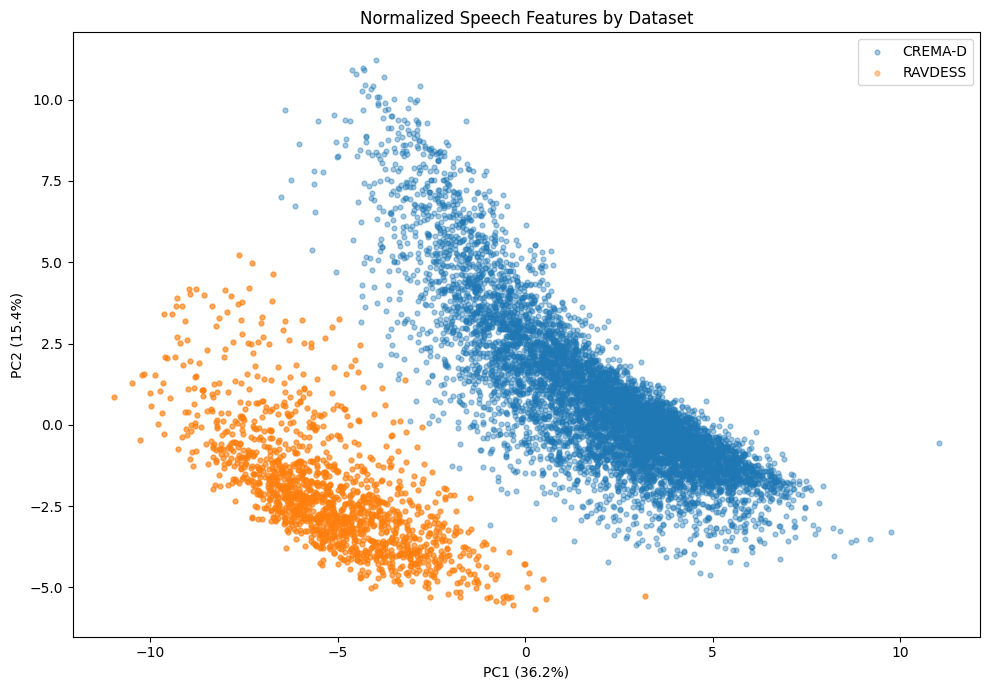

Explained variance:
[0.36241658 0.15428756]
Total: 0.5167041360706508


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

df = pd.read_csv(
    r"C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\processed\speech_features_normalized.csv"
)

exclude_cols = [
    "file_id",
    "dataset",
    "file",
    "speaker",
    "emotion",
    "emotion_id"
]

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

X = df[feature_cols]
y = df["dataset"]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))

for dataset in y.unique():
    mask = y == dataset
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=dataset,
        alpha=0.4,
        s=12
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title("Normalized Speech Features by Dataset")
plt.legend()
plt.tight_layout()

plt.savefig(
    r"C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\outputs\normalized_speech_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Explained variance:")
print(pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler

INPUT_FILE = Path("../data/processed/speech_features_normalized.csv")
OUTPUT_FILE = Path("../data/processed/speech_features_domain_normalized.csv")

df = pd.read_csv(INPUT_FILE)

exclude_cols = [
    "file_id",
    "dataset",
    "file",
    "speaker",
    "emotion",
    "emotion_id"
]

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

df_normalized = df.copy()

for dataset in df["dataset"].unique():
    mask = df["dataset"] == dataset

    scaler = StandardScaler()
    df_normalized.loc[mask, feature_cols] = scaler.fit_transform(
        df.loc[mask, feature_cols]
    )

df_normalized.to_csv(OUTPUT_FILE, index=False)

print("=" * 50)
print("Dataset-wise normalization complete")
print("=" * 50)

print("Shape:", df_normalized.shape)
print("Features normalized:", len(feature_cols))
print("Saved to:", OUTPUT_FILE)

for dataset in df_normalized["dataset"].unique():
    subset = df_normalized.loc[
        df_normalized["dataset"] == dataset,
        feature_cols
    ]

    print(f"\n{dataset}")
    print("Mean:", subset.mean().mean())
    print("Average std:", subset.std().mean())

Dataset-wise normalization complete
Shape: (10322, 51)
Features normalized: 45
Saved to: ..\data\processed\speech_features_domain_normalized.csv

CREMA-D
Mean: -6.237856141224565e-18
Average std: 0.9778434776117355

RAVDESS
Mean: -2.820514740831664e-16
Average std: 0.977947575083526


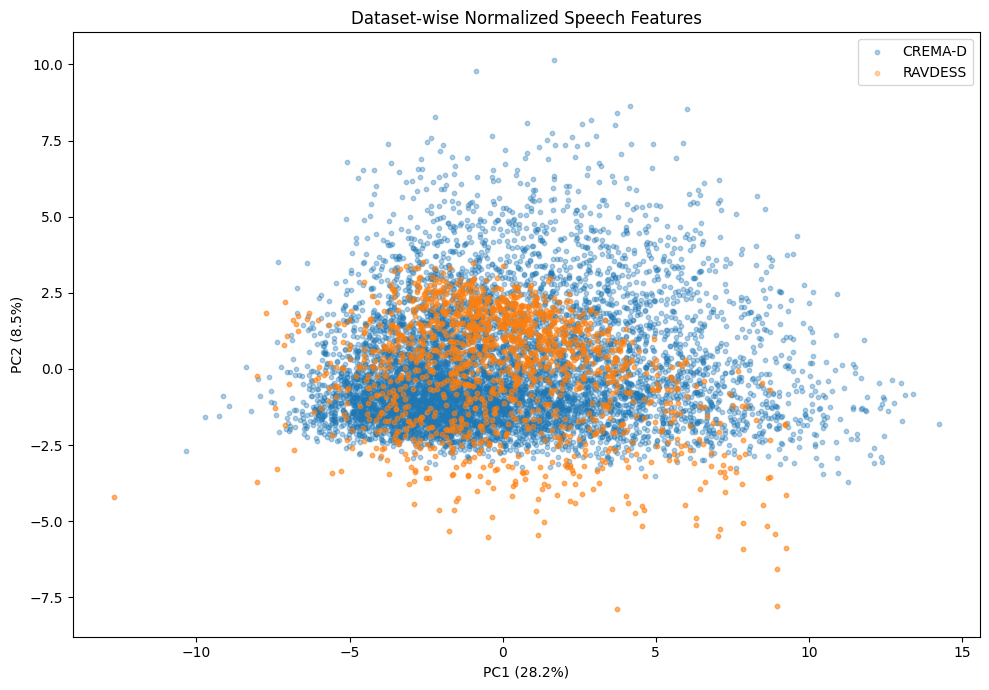

Explained variance:
[0.28235682 0.08468404]
Total: 0.36704085283374216


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

INPUT_FILE = "../data/processed/speech_features_domain_normalized.csv"

df = pd.read_csv(INPUT_FILE)

exclude_cols = [
    "file_id",
    "dataset",
    "file",
    "speaker",
    "emotion",
    "emotion_id"
]

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

X = df[feature_cols].values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))

for dataset in df["dataset"].unique():
    mask = df["dataset"] == dataset

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=10,
        alpha=0.35,
        label=dataset
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Dataset-wise Normalized Speech Features")
plt.legend()
plt.tight_layout()
plt.show()

print("Explained variance:")
print(pca.explained_variance_ratio_)

print(
    "Total:",
    pca.explained_variance_ratio_.sum()
)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df[feature_cols]
y = df["dataset"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Dataset classification accuracy:", accuracy)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        pred
    )
)

Dataset classification accuracy: 1.0

Classification report:
              precision    recall  f1-score   support

     CREMA-D       1.00      1.00      1.00      1489
     RAVDESS       1.00      1.00      1.00       576

    accuracy                           1.00      2065
   macro avg       1.00      1.00      1.00      2065
weighted avg       1.00      1.00      1.00      2065



In [7]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

FILE = "../data/processed/speech_features_normalized.csv"

df = pd.read_csv(FILE)

exclude_cols = [
    "file_id",
    "dataset",
    "file",
    "speaker",
    "emotion",
    "emotion_id"
]

feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
]

X = df[feature_cols]
y = df["dataset"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Dataset classification accuracy:")
print(accuracy_score(y_test, pred))

print("\nClassification report:")
print(classification_report(y_test, pred))

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print("\nTop dataset-dependent features:")
print(importance.head(20).to_string(index=False))

Dataset classification accuracy:
1.0

Classification report:
              precision    recall  f1-score   support

     CREMA-D       1.00      1.00      1.00      1489
     RAVDESS       1.00      1.00      1.00       576

    accuracy                           1.00      2065
   macro avg       1.00      1.00      1.00      2065
weighted avg       1.00      1.00      1.00      2065


Top dataset-dependent features:
    feature  importance
 energy_min    0.184448
mfcc_1_mean    0.114919
mfcc_2_mean    0.105922
 mfcc_1_std    0.088658
   zcr_mean    0.087973
   duration    0.075141
mfcc_3_mean    0.070644
    shimmer    0.052426
    zcr_max    0.040801
 mfcc_2_std    0.038833
    zcr_min    0.025079
    zcr_std    0.021310
mfcc_11_std    0.020573
energy_mean    0.012972
 mfcc_7_std    0.007924
 mfcc_9_std    0.006953
mfcc_4_mean    0.006574
mfcc_7_mean    0.006316
pitch_range    0.006152
mfcc_13_std    0.005769


In [8]:
top_features = importance.head(10)["feature"].tolist()

print("Top 10 features:")
for f in top_features:
    print(f)

X_top = df[top_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_top,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("\nAccuracy using top 10 features:")
print(accuracy_score(y_test, pred))

Top 10 features:
energy_min
mfcc_1_mean
mfcc_2_mean
mfcc_1_std
zcr_mean
duration
mfcc_3_mean
shimmer
zcr_max
mfcc_2_std

Accuracy using top 10 features:
1.0


In [9]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

FILE = "../data/processed/speech_features_normalized.csv"

df = pd.read_csv(FILE)

exclude_cols = [
    "file_id",
    "dataset",
    "file",
    "speaker",
    "emotion",
    "emotion_id"
]

feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
]

top_10 = [
    "energy_min",
    "mfcc_1_mean",
    "mfcc_2_mean",
    "mfcc_1_std",
    "zcr_mean",
    "duration",
    "mfcc_3_mean",
    "shimmer",
    "zcr_max",
    "mfcc_2_std"
]

remaining_features = [
    c for c in feature_cols
    if c not in top_10
]

X = df[remaining_features]
y = df["dataset"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Features remaining:", len(remaining_features))
print("Dataset classification accuracy:")
print(accuracy_score(y_test, pred))

print("\nClassification report:")
print(classification_report(y_test, pred))

Features remaining: 35
Dataset classification accuracy:
0.9970944309927361

Classification report:
              precision    recall  f1-score   support

     CREMA-D       1.00      1.00      1.00      1489
     RAVDESS       1.00      0.99      0.99       576

    accuracy                           1.00      2065
   macro avg       1.00      0.99      1.00      2065
weighted avg       1.00      1.00      1.00      2065



In [10]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

FILE = "../data/processed/speech_features_normalized.csv"

df = pd.read_csv(FILE)

exclude_cols = [
    "file_id",
    "dataset",
    "file",
    "speaker",
    "emotion",
    "emotion_id"
]

feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
]

df_norm = df.copy()

for dataset in df["dataset"].unique():

    mask = df["dataset"] == dataset

    scaler = StandardScaler()

    df_norm.loc[mask, feature_cols] = scaler.fit_transform(
        df.loc[mask, feature_cols]
    )

X = df_norm[feature_cols]
y = df_norm["dataset"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Dataset classification accuracy:")
print(accuracy_score(y_test, pred))

print("\nClassification report:")
print(classification_report(y_test, pred))

Dataset classification accuracy:
1.0

Classification report:
              precision    recall  f1-score   support

     CREMA-D       1.00      1.00      1.00      1489
     RAVDESS       1.00      1.00      1.00       576

    accuracy                           1.00      2065
   macro avg       1.00      1.00      1.00      2065
weighted avg       1.00      1.00      1.00      2065

